# 🚀 Credit Card Default Prediction
End-to-End Machine Learning Project

This notebook covers:
- Data Loading
- EDA
- Feature Engineering
- Preprocessing (Scaling, Encoding)
- Pipelines
- Model Training & Evaluation


## 📦 Step 1: Import Libraries

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder ,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 📂 Step 2: Load Dataset

In [3]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 🔎 Step 3: Data Info & Statistics

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

## 📊 Step 4: Exploratory Data Analysis

### Univariate Analysis

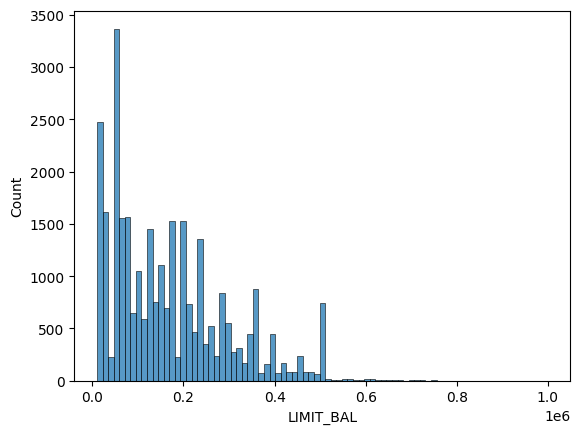

In [5]:
sns.histplot(df['LIMIT_BAL'])
plt.show()

### Bivariate Analysis

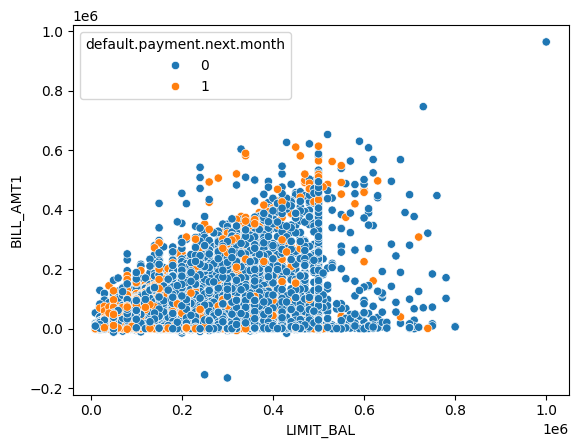

In [6]:
sns.scatterplot(x='LIMIT_BAL', y='BILL_AMT1', hue='default.payment.next.month', data=df)
plt.show()

### Multivariate Analysis

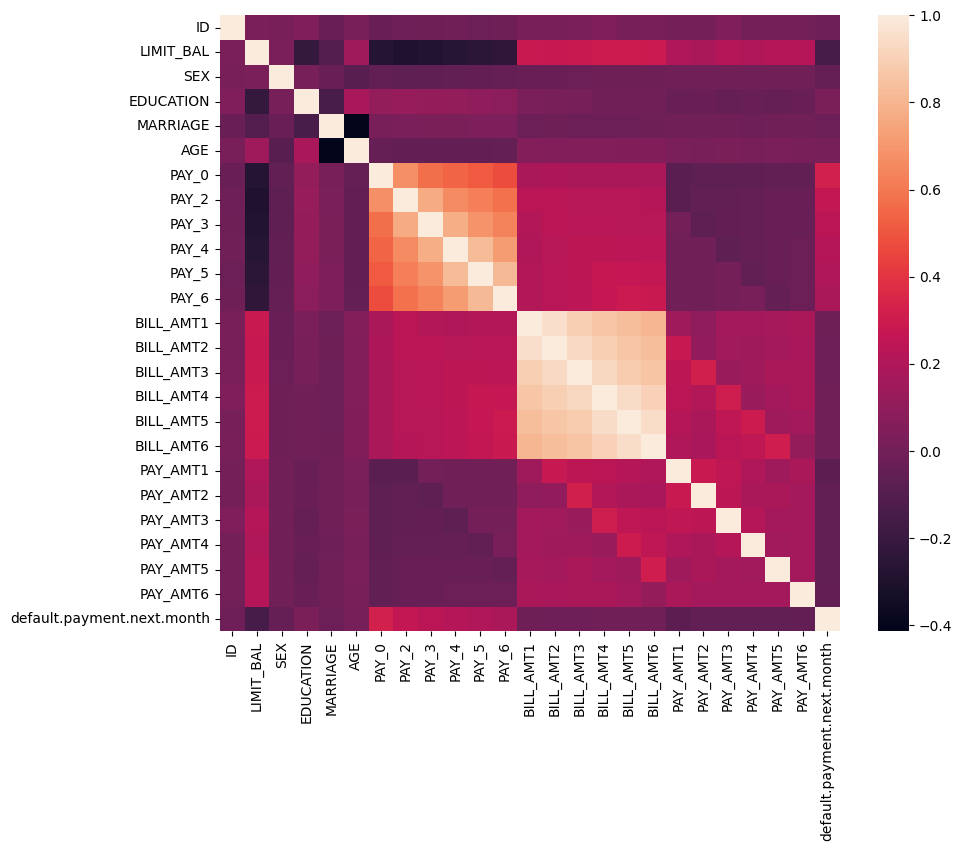

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)
plt.show()

## 🛠️ Step 5: Feature Engineering

In [8]:
df['credit_utilization'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)
df['avg_delay'] = (df['PAY_0'] + df['PAY_2'] + df['PAY_3']) / 3
df[['credit_utilization', 'avg_delay']].head()

,credit_utilization,avg_delay
0,0.195640,1.000000
1,0.022350,0.333333
2,0.324874,0.000000
3,0.939781,0.000000
4,0.172337,-0.666667


## 🎯 Step 6: Define Features & Target

In [9]:
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

## 🔤 Step 7: Identify Column Types

In [10]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns
print(num_cols)
print(cat_cols)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'credit_utilization', 'avg_delay'],
      dtype='object')
Index([], dtype='object')


## 🔄 Step 8: Preprocessing (Column Transformer)

In [49]:
# def log_transform(x):
#     return np.log1p(x)

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', Pipeline([
#             ('log', FunctionTransformer(log_transform)),
#             ('scaler', StandardScaler())
#         ]), num_cols),

#         ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
#     ]
# )

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

## 🔗 Step 9: Pipelines

In [50]:
# pipeline_lr = Pipeline([
#     ('preprocessing', preprocessor),
#     ('model', LogisticRegression())
# ])

# pipeline_knn = Pipeline([
#     ('preprocessing', preprocessor),
#     ('model', KNeighborsClassifier())
# ])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),        # handle missing values
    ('power', PowerTransformer(method='yeo-johnson')),    # 🔥 main step
    ('scaler', StandardScaler())                          # optional but recommended
])


## ✂️ Step 10: Train-Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Step 11: Train Models

In [52]:
pipeline_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_knn = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])


## 📈 Step 12: Predictions

In [53]:
pipeline_lr.fit(X_train, y_train)
pipeline_knn.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_knn = pipeline_knn.predict(X_test)

## 📊 Step 13: Evaluation

In [54]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Logistic Regression Accuracy: 0.802
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      4687
           1       0.65      0.21      0.32      1313

    accuracy                           0.80      6000
   macro avg       0.73      0.59      0.60      6000
weighted avg       0.78      0.80      0.76      6000

KNN Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4687
           1       0.53      0.33      0.41      1313

    accuracy                           0.79      6000
   macro avg       0.68      0.63      0.64      6000
weighted avg       0.77      0.79      0.77      6000



## 📉 Confusion Matrix

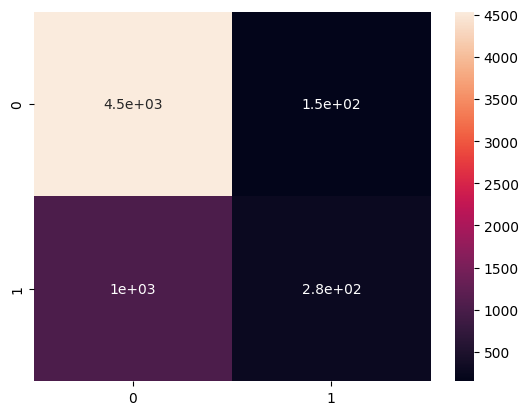

In [59]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr),annot=True)
plt.show()

## 🎯 Step 14: Prediction Function

In [56]:
def predict_new(data):
    df_new = pd.DataFrame([data])
    return pipeline_lr.predict(df_new)

sample = X.iloc[0].to_dict()
predict_new(sample)

array([1])

# USING DIFFERENT TRANSFORMATION TECHNIQUES

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# =========================
# NUMERIC PIPELINES
# =========================

# 1. No scaling
num_none = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# 2. RobustScaler
num_robust = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 3. Yeo-Johnson
num_yeo = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# =========================
# FUNCTION TO TEST
# =========================
def evaluate_pipeline(num_pipeline, name):
    
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ])
    
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.4f}")


# =========================
# RUN COMPARISON
# =========================
evaluate_pipeline(num_none, "No Scaling")
evaluate_pipeline(num_robust, "RobustScaler")
evaluate_pipeline(num_yeo, "Yeo-Johnson")

C:\Users\surendra purohit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


No Scaling Accuracy: 0.8028
RobustScaler Accuracy: 0.8085
Yeo-Johnson Accuracy: 0.8020
